In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

from odin_sequencer.rpc.client import OdinSequencerClient, OdinSequencerClientError

seq = OdinSequencerClient("127.0.0.1")
test_device = seq.get_context("test_device")

In [2]:
result = seq.execute("add", 1, 2)
print(f">>> Result is {result} of type {type(result)}")

Adding 1 and 2
Add sequence loop count 0
Add sequence loop count 1
Add sequence loop count 2
Add sequence loop count 3
Add sequence loop count 4
Add sequence loop count 5
Add sequence loop count 6
Add sequence loop count 7
Add sequence loop count 8
Add sequence loop count 9
Done adding, result is 3
>>> Result is 3 of type <class 'int'>


In [3]:
result = test_device.execute("read_reg")
print(f">>> Register value is {result}")

>>> Register value is 123


In [4]:
result = test_device.read_reg()
print(result)

123


In [5]:
try:
    result = test_device.read_missing()
except OdinSequencerClientError as error:
    print(error)

Error calling method execute for client id 297c-dd29 : 'TestDevice' object has no attribute 'read_missing'


In [3]:
seq.execute("exceptional_add", a=7, b=32)

Exceptional add


39

In [4]:
seq.execute("abortable_sequence")

Loop count 0
Loop count 10
Loop count 20
Loop count 30
Keyboard interrupt received, aborting execution
Aborting sequence
Sequence complete


In [2]:
seq.reload()

True

Numpy array created with shape:[1024, 1024]


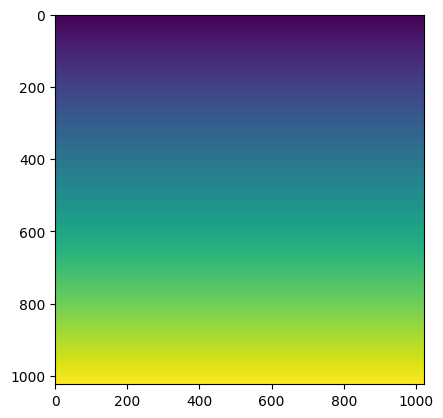

In [7]:
result = seq.execute("array_test", shape=[1024,1024])
_ = plt.imshow(result)

Sine wave generated with frequency:5


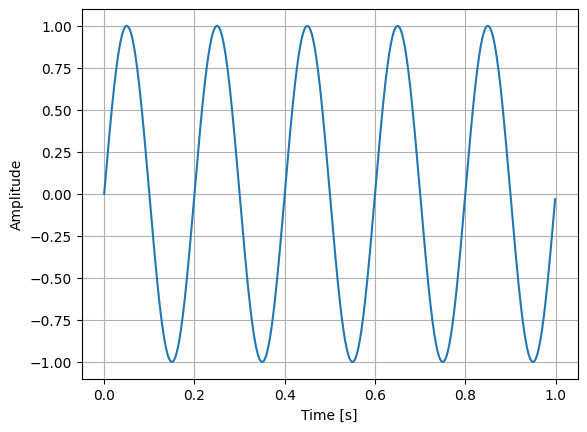

In [8]:
t, signal = seq.execute("sine_test", freq=5, duration=1, rate=1000)
plt.plot(t, signal)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)